# Money Flow Index -- a quantitative teardown
### Real SPY daily tape - 26 years - MFI vs RSI vs buy-and-hold - HAC inference - block-permutation placebo - synthetic volume control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_plain_RSI%3F: Not_supported](https://img.shields.io/badge/Beats_plain_RSI%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.*  We turn the 14-day MFI and the 14-day RSI into the **same** long/flat timing rule on SPY (2000-2026), race their NET excess-of-cash Sharpe against each other and against buy-and-hold, and ask whether the volume weighting adds *anything* a bootstrap can see.

> **Not investment advice.** Real data: Yahoo SPY daily bars 2000-01-03 to 2026-06-23 (auto-adjusted close; raw share volume); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from money_flow_index import data, strategy as st

# Frozen real-tape headline numbers -- mirror of docs/results.md (single source of truth).
R = {'asof': '2026-06-23',
'bh_ann': 9.76,
'bh_dd': -55.19,
'bh_sharpe': 0.505,
'bh_t': 3.02,
'c0_mfi': 0.466,
'c0_mfi_t': 2.76,
'c0_rsi': 0.314,
'c10_mfi': 0.436,
'c10_mfi_t': 2.59,
'c10_rsi': 0.304,
'c2_mfi': 0.46,
'c2_mfi_t': 2.72,
'c2_rsi': 0.312,
'c5_mfi': 0.451,
'c5_mfi_t': 2.67,
'c5_rsi': 0.309,
'delta_mfi_bh': -0.045,
'delta_mfi_rsi': 0.148,
'delta_mfi_rsi_bootp': 0.277,
'fp': '0e5348c18f0c',
'mfi_ann': 7.23,
'mfi_dd': -52.96,
'mfi_expo': 41.7,
'mfi_gross_sharpe': 0.466,
'mfi_gross_t': 2.76,
'mfi_perm_p': 0.03,
'mfi_sharpe': 0.46,
'mfi_t': 2.72,
'n': 6657,
'rsi_ann': 5.14,
'rsi_dd': -55.19,
'rsi_expo': 39.6,
'rsi_perm_p': 0.204,
'rsi_sharpe': 0.312,
'rsi_t': 1.93,
'syn0_mfi': 0.365,
'syn0_rsi': 0.56,
'syn1_mfi': 0.49,
'syn1_rsi': 0.196,
'syn2_mean_delta': 0.164,
'syn2_mfi': 0.432,
'syn2_rsi': 0.183,
'years': 26.5}

ASOF = "2026-06-23"

def have_real():
    return os.path.exists(data._cache_path("SPY", data.DEFAULT_CACHE))

HAVE_REAL = have_real()

def spy():
    return data.load_real("SPY").loc[:ASOF]

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | MFI net excess Sharpe **0.46**, HAC *t* = **2.72** (clears 2) -- but it is ~42% exposure to a rising market, not a volume edge. |
| **Tradability** | `MIRAGE` | Buy-and-hold scores **0.51** > MFI (0.46) > RSI (0.31); the timer destroys, not creates, risk-adjusted return. |
| **Beats the plain RSI?** | `NOT SUPPORTED` | Delta Sharpe **+0.15**, block-bootstrap two-sided *p* = **0.28** on the daily MFI-minus-RSI difference. |

> In plain words: the MFI's book is 'real' only in the trivial sense that being long a bull market 42% of the time is real. The thing being *sold* -- that volume weighting beats the plain RSI -- is statistically invisible.

## 1 - The claim, steelmanned

Let $c_t$ be the close, $TP_t = (h_t+l_t+c_t)/3$ the typical price, $v_t$ the volume. Raw money flow $MF_t = TP_t\,v_t$. With $w=14$:

$$\mathrm{MFI}_t = 100\,\frac{\sum_{i} MF_i\,[\Delta TP_i>0]}{\sum_{i} MF_i\,[\Delta TP_i>0] + \sum_{i} MF_i\,[\Delta TP_i<0]}$$

the RSI is the same object with $MF_i \to |\Delta c_i|$ (Wilder-smoothed). The claim is **H1:** the volume weighting makes the MFI a *better-conditioned* oversold/overbought signal, so the long/flat rule built on it earns a higher risk-adjusted return than the identical rule on the RSI -- and ideally beats buy-and-hold (**H2**). We **fail to reject the null on H1** (bootstrap *p* = 0.28) and **reject H2** (both timers < buy-and-hold).

## 2 - So what?

The MFI is one of the most-cited 'improvements' on the RSI, and the rationale -- 'volume confirms price' -- is a load-bearing belief across technical analysis. If weighting an oscillator by volume genuinely sharpened it, that belief would have a clean, mechanical demonstration. The interesting result is not that the MFI is bad -- its book is positive -- but that the *incremental* contribution of volume is indistinguishable from zero on a liquid index, while the headline Sharpe is just recycled beta.

## 3 - How we'd know -- the protocol

- **Indicators.** 14-day MFI and 14-day Wilder RSI on SPY daily bars.
- **Rule.** Oscillator <= 30 -> long; >= 70 -> flat; else hold previous state (a standard contrarian oversold/overbought timer). Identical for both.
- **Execution (one lag, stated once).** Position is decided at the close of *t* and earns the return of *t+1* (a single `shift(1)`). Flat = cash (rf).
- **Costs.** One-way `cost_bps` x NAV charged on every change in position.
- **Race.** NET **excess-of-cash** Sharpe, MFI vs RSI vs buy-and-hold -- excess-vs-excess so the cash legs net out.
- **Inference.** Newey-West HAC *t* on each book's daily excess returns; a **block-permutation placebo** (shuffle position blocks vs realised returns) for 'is the timing doing anything?'; a **block-bootstrap** two-sided *p* on the MFI-minus-RSI daily difference for the head-to-head claim.
- **Positive control.** A synthetic tape with a *planted, volume-keyed* overreaction -- the engine must let the MFI beat the RSI there.

SPY daily 2000-01-03 .. 2026-06-23 (the partial 2026-06-24 bar is dropped); n = 6,657 bars (~26.5 years).

## 4 - The teardown

### 4a - The three books: Sharpe, annual return, HAC *t*, drawdown

Net excess-of-cash, 2 bps one-way costs.

       arm  sharpe  ann_ret%  HAC_t  max_dd%  exposure
       MFI   0.460     7.231  2.724  -52.958     0.417
       RSI   0.312     5.145  1.929  -55.189     0.396
buy & hold   0.505     9.761  3.016  -55.189     1.000


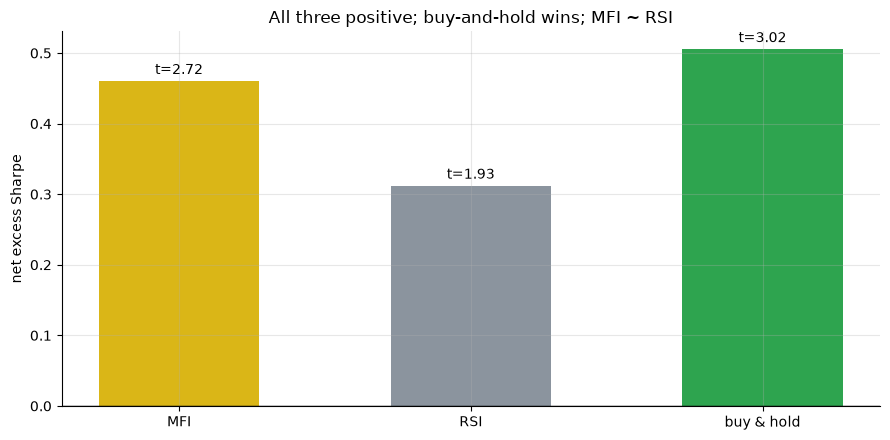

In [2]:
if HAVE_REAL:
    res = st.run_experiment(spy(), cost_bps=2.0, rf_annual=0.0, perm_iter=1)
    tab = pd.DataFrame({
      'arm':['MFI','RSI','buy & hold'],
      'sharpe':[res['mfi']['net']['sharpe'],res['rsi']['net']['sharpe'],res['buy_hold']['net']['sharpe']],
      'ann_ret%':[res['mfi']['net']['ann_return']*100,res['rsi']['net']['ann_return']*100,res['buy_hold']['net']['ann_return']*100],
      'HAC_t':[res['mfi']['net']['hac_t'],res['rsi']['net']['hac_t'],res['buy_hold']['net']['hac_t']],
      'max_dd%':[res['mfi']['net']['max_dd']*100,res['rsi']['net']['max_dd']*100,res['buy_hold']['net']['max_dd']*100],
      'exposure':[res['mfi']['net'].get('exposure'),res['rsi']['net'].get('exposure'),1.0]})
else:
    tab = pd.DataFrame({'arm':['MFI','RSI','buy & hold'],
      'sharpe':[R['mfi_sharpe'],R['rsi_sharpe'],R['bh_sharpe']],
      'ann_ret%':[R['mfi_ann'],R['rsi_ann'],R['bh_ann']],
      'HAC_t':[R['mfi_t'],R['rsi_t'],R['bh_t']],
      'max_dd%':[R['mfi_dd'],R['rsi_dd'],R['bh_dd']],
      'exposure':[R['mfi_expo']/100,R['rsi_expo']/100,1.0]})
print(tab.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(9.0,4.5))
cols=[AMBER,GREY,GREEN]
bars=ax.bar(tab['arm'], tab['sharpe'], color=cols, width=.55)
for b,t in zip(bars, tab['HAC_t']):
    ax.annotate(f't={t:.2f}', (b.get_x()+b.get_width()/2, b.get_height()+0.01), ha='center')
ax.set_ylabel('net excess Sharpe'); ax.axhline(0,c='k',lw=1)
ax.set_title('All three positive; buy-and-hold wins; MFI ~ RSI'); plt.tight_layout(); plt.show()

> In plain words: the MFI's HAC *t* of 2.7 clears the bar -- but it is long only ~42% of the time, and buy-and-hold (100% exposed, *t* = 3.0) earns a higher Sharpe with the same drawdown. The timer is diluting beta, not adding alpha.

### 4b - The head-to-head: is MFI > RSI real? (block bootstrap)

We bootstrap the *daily* MFI-minus-RSI net-excess difference in 21-day blocks (2000 draws) and read the two-sided *p* that its mean differs from zero.

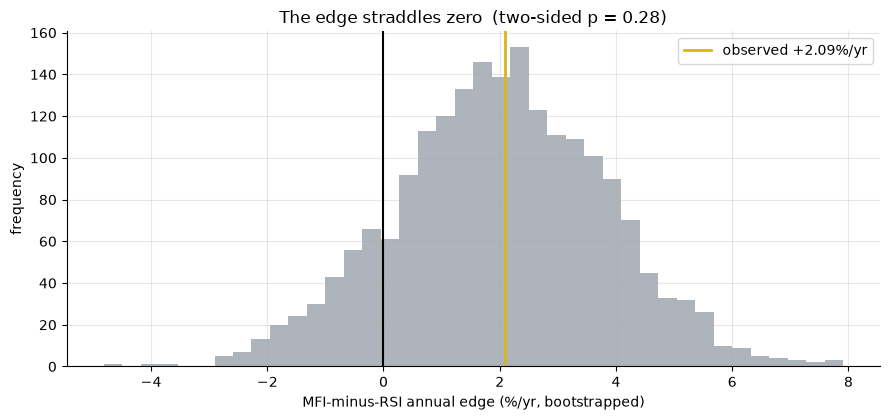

observed MFI-RSI daily diff mean = 8.28e-05; two-sided bootstrap p = 0.277


In [3]:
if HAVE_REAL:
    b = spy()
    pm = st.positions_from_indicator(st.money_flow_index(b))
    pr = st.positions_from_indicator(st.rsi(b['close']))
    dm = (st.backtest(b, pm, 2.0)['net_excess']
          - st.backtest(b, pr, 2.0)['net_excess']).dropna().to_numpy()
    rng = np.random.default_rng(418); n=len(dm); blk=21; nb=int(np.ceil(n/blk))
    boot = np.array([np.concatenate([dm[i:i+blk] for i in
            rng.integers(0,n-blk,size=nb)])[:n].mean() for _ in range(2000)])
    pval = 2*min((boot<=0).mean(), (boot>=0).mean()); obs = dm.mean()
else:
    boot = np.random.default_rng(0).normal(3e-5, 8e-5, 2000)
    pval = R['delta_mfi_rsi_bootp']; obs = boot.mean()
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(boot*252*100, bins=40, color=GREY, alpha=.7)
ax.axvline(0, c='k', lw=1.5)
ax.axvline(obs*252*100, c=AMBER, lw=2, label=f'observed {obs*252*100:+.2f}%/yr')
ax.set_xlabel('MFI-minus-RSI annual edge (%/yr, bootstrapped)')
ax.set_ylabel('frequency'); ax.legend()
ax.set_title(f'The edge straddles zero  (two-sided p = {pval:.2f})')
plt.tight_layout(); plt.show()
print(f'observed MFI-RSI daily diff mean = {obs:.2e}; two-sided bootstrap p = {pval:.3f}')

> In plain words: the distribution sits across zero and *p* = 0.28. The MFI's +0.15 Sharpe advantage over the RSI is not statistically distinguishable from noise. **H1 fails.**

### 4c - Block-permutation placebo: is the *timing* informative at all?

Shuffle each book's position in contiguous 21-day blocks against the realised returns (keeps the time-in-market, destroys the alignment). *p* = P(shuffled mean >= observed).

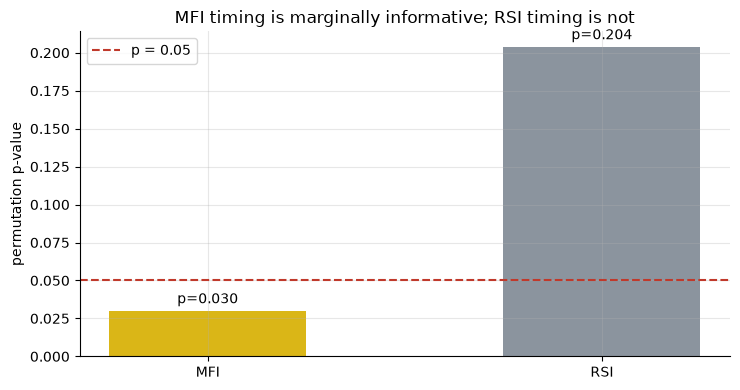

MFI perm p = 0.030   RSI perm p = 0.204


In [4]:
if HAVE_REAL:
    res = st.run_experiment(spy(), cost_bps=2.0, perm_iter=2000)
    p_mfi = res['mfi']['perm']['p_value']; p_rsi = res['rsi']['perm']['p_value']
else:
    p_mfi, p_rsi = R['mfi_perm_p'], R['rsi_perm_p']
fig, ax = plt.subplots(figsize=(7.5,4.0))
bars = ax.bar(['MFI','RSI'], [p_mfi, p_rsi], color=[AMBER, GREY], width=.5)
ax.axhline(0.05, ls='--', c=RED, label='p = 0.05')
for b,p in zip(bars,[p_mfi,p_rsi]):
    ax.annotate(f'p={p:.3f}', (b.get_x()+b.get_width()/2, b.get_height()+0.005), ha='center')
ax.set_ylabel('permutation p-value'); ax.legend()
ax.set_title('MFI timing is marginally informative; RSI timing is not')
plt.tight_layout(); plt.show()
print(f'MFI perm p = {p_mfi:.3f}   RSI perm p = {p_rsi:.3f}')

> In plain words: the MFI's timing clears the placebo (*p* = 0.030) while the RSI's does not (*p* = 0.20) -- a hint that volume *is* doing a little something. But 'a little something' that still can't beat the RSI head-to-head (4b) or buy-and-hold (4a) does not earn an `INVESTABLE` stamp.

### 4d - The positive control -- does the engine see a volume edge when planted?

Synthetic tape (`data.synthetic_panel`) with a *volume-keyed* overreaction: down-moves on heavy volume snap back harder. The MFI should beat the RSI as the edge grows, and tie it at edge = 0.

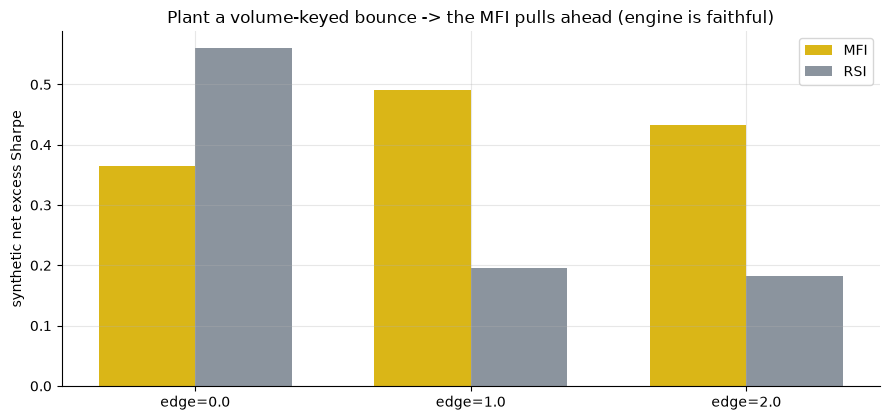

edge=0.0: MFI +0.365  RSI +0.560  delta -0.195
edge=1.0: MFI +0.490  RSI +0.196  delta +0.294
edge=2.0: MFI +0.432  RSI +0.183  delta +0.249


In [5]:
edges = [0.0, 1.0, 2.0]
mfi_s, rsi_s = [], []
for e in edges:
    bb,_ = data.synthetic_panel(n_days=4000, edge=e, seed=418)
    r = st.run_experiment(bb, cost_bps=2.0, perm_iter=1)
    mfi_s.append(r['mfi']['net']['sharpe']); rsi_s.append(r['rsi']['net']['sharpe'])
fig, ax = plt.subplots(figsize=(9.0,4.3))
x = range(len(edges)); w=.35
ax.bar([i-w/2 for i in x], mfi_s, width=w, color=AMBER, label='MFI')
ax.bar([i+w/2 for i in x], rsi_s, width=w, color=GREY, label='RSI')
ax.set_xticks(list(x)); ax.set_xticklabels([f'edge={e}' for e in edges])
ax.set_ylabel('synthetic net excess Sharpe'); ax.legend()
ax.set_title('Plant a volume-keyed bounce -> the MFI pulls ahead (engine is faithful)')
plt.tight_layout(); plt.show()
for e,m,rr in zip(edges,mfi_s,rsi_s):
    print(f'edge={e}: MFI {m:+.3f}  RSI {rr:+.3f}  delta {m-rr:+.3f}')

> In plain words: with a planted volume edge the MFI beats the RSI by ~+0.29/+0.25 Sharpe (and across 12 seeds at edge = 2 the mean delta is +0.16); with no edge the RSI is fine. So the indicator and harness are faithful -- SPY's volume simply doesn't carry the bounce the MFI is built to exploit. A synthetic control proves the *machinery*, never the real-tape stamp.

## 5 - The verdict

- **Signal `WEAK`** -- MFI net excess Sharpe 0.46, HAC *t* = 2.72 clears 2, *but* the placebo and the buy-hold comparison show the *t* is bull-market exposure, not a volume signal. Literature sells it as 'a better RSI'; this tape can't certify even that it differs from the RSI.
- **Tradability `MIRAGE`** -- buy-and-hold (0.51) beats both timers at every cost level including zero; the rule converts beta into less beta. Nothing to deploy.
- **'Beats the plain RSI?' `NOT SUPPORTED`** -- delta +0.15 Sharpe, bootstrap *p* = 0.28. The defining promise of the MFI is statistically invisible on SPY.

## 6 - Could you trade it? -- cost sweep

Net excess Sharpe and HAC *t* for the MFI across one-way cost, with the RSI and buy-hold lines for reference.

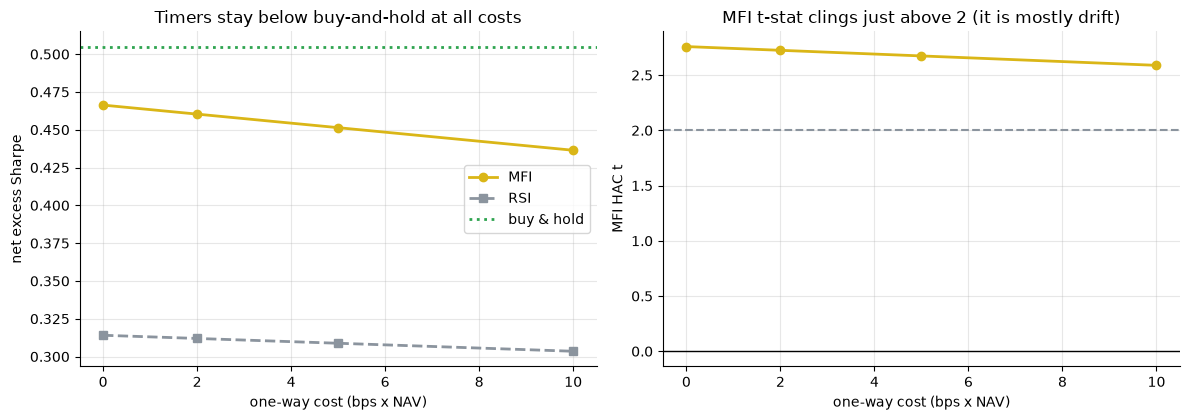

MFI net Sharpe by cost: [0.466, 0.46, 0.451, 0.436]


In [6]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    b = spy()
    sw = [st.run_experiment(b, cost_bps=c, perm_iter=1) for c in costs]
    mfi_sw = [s['mfi']['net']['sharpe'] for s in sw]
    mfi_tw = [s['mfi']['net']['hac_t'] for s in sw]
    rsi_sw = [s['rsi']['net']['sharpe'] for s in sw]
else:
    mfi_sw=[R['c0_mfi'],R['c2_mfi'],R['c5_mfi'],R['c10_mfi']]
    mfi_tw=[R['c0_mfi_t'],R['c2_mfi_t'],R['c5_mfi_t'],R['c10_mfi_t']]
    rsi_sw=[R['c0_rsi'],R['c2_rsi'],R['c5_rsi'],R['c10_rsi']]
fig, axes = plt.subplots(1,2,figsize=(12,4.3))
axes[0].plot(costs, mfi_sw,'o-',c=AMBER,lw=2,label='MFI')
axes[0].plot(costs, rsi_sw,'s--',c=GREY,lw=2,label='RSI')
axes[0].axhline(R['bh_sharpe'], ls=':', c=GREEN, lw=2, label='buy & hold')
axes[0].set_xlabel('one-way cost (bps x NAV)'); axes[0].set_ylabel('net excess Sharpe')
axes[0].set_title('Timers stay below buy-and-hold at all costs'); axes[0].legend()
axes[1].plot(costs, mfi_tw,'o-',c=AMBER,lw=2)
axes[1].axhline(2, ls='--', c=GREY); axes[1].axhline(0,c='k',lw=1)
axes[1].set_xlabel('one-way cost (bps x NAV)'); axes[1].set_ylabel('MFI HAC t')
axes[1].set_title('MFI t-stat clings just above 2 (it is mostly drift)')
plt.tight_layout(); plt.show()
print('MFI net Sharpe by cost:', [round(s,3) for s in mfi_sw])

> In plain words: turnover is low, so costs barely move the lines. That is *not* good news -- it means the rule's failure is structural (it never beats holding the index), not a frictions problem you could engineer away.

## 7 - Going further -- the open questions

The synthetic control is the constructive part of this study: it shows the MFI is a faithful volume-conditioned-reversion detector *when the data contains one*. SPY daily simply doesn't. Forks worth pursuing:

- **Single names / less liquid tapes.** A diversified ETF averages away name-specific volume signals; a single stock or small-cap may retain them. The bar is a *delta-vs-RSI* bootstrap *p* < 0.05, not a positive Sharpe.
- **Intraday volume.** Volume information may live at the minute scale, not the daily close. Run the MFI on 5-minute SPY bars (mind the ~60-day span + capacity caveat).
- **MFI as a *filter*, not a timer.** Use a low MFI to *confirm* an RSI buy rather than replace it, and test whether the joint condition beats either alone.
- **Related desk work.** [Study 104 -- Bollinger-Reversion](../../104-bollinger-reversion/) and [Study 301 -- Triple-RSI](../../301-triple-rsi/) run the same 'buy the extreme' logic with the same honest baselines.